# Cayley Graph of $(\mathbb{Z}/2\mathbb{Z}) * (\mathbb{Z}/3\mathbb{Z})$

Layout tuned to match the hand-drawn reference: branching planar shape, black edges, and red/green/blue node levels.

In [13]:
import math
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import networkx as nx

In [14]:
# Group presentation: <a,b | a^2=e, b^3=e>
gens = ['a', 'b', 'b2']
inv = {'a': 'a', 'b': 'b2', 'b2': 'b'}

def reduce_word(word):
    w = list(word)
    changed = True
    while changed:
        changed = False

        st = []
        for g in w:
            if st and inv[g] == st[-1]:
                st.pop()
                changed = True
            else:
                st.append(g)
        w = st

        out = []
        i = 0
        while i < len(w):
            if w[i] in ('b', 'b2'):
                total = 0
                while i < len(w) and w[i] in ('b', 'b2'):
                    total += 1 if w[i] == 'b' else 2
                    i += 1
                r = total % 3
                if r == 1:
                    out.append('b')
                elif r == 2:
                    out.append('b2')
                else:
                    changed = True
            else:
                out.append(w[i])
                i += 1

        if out != w:
            changed = True
        w = out

    return tuple(w)

def mul_right(w, g):
    return reduce_word(list(w) + [g])

In [15]:
def build_ball(radius=6):
    e = tuple()
    G = nx.Graph()
    G.add_node(e)

    dist = {e: 0}
    parent = {e: None}
    q = deque([e])

    while q:
        u = q.popleft()
        if dist[u] == radius:
            continue
        for g in gens:
            v = mul_right(u, g)
            G.add_edge(u, v, gen=g)
            if v not in dist:
                dist[v] = dist[u] + 1
                parent[v] = u
                q.append(v)

    keep = {v for v, d in dist.items() if d <= radius}
    G = G.subgraph(keep).copy()
    return G, dist, parent

radius = 8
G, dist_e, parent_e = build_ball(radius=radius)
print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Radius: {radius}')

Nodes: 106, Edges: 127, Radius: 8


In [16]:
# Build a BFS spanning tree (for layout only), but keep all edges for drawing
tree_edges = [(p, v) for v, p in parent_e.items() if p is not None]
T = nx.Graph()
T.add_nodes_from(G.nodes())
T.add_edges_from(tree_edges)

# Choose a central root (middle of a tree diameter) to get the top/bottom branching look
def farthest_node(H, s):
    d = nx.single_source_shortest_path_length(H, s)
    return max(d, key=d.get), d

u, _ = farthest_node(T, tuple())
v, _ = farthest_node(T, u)
diam_path = nx.shortest_path(T, u, v)
root = diam_path[len(diam_path) // 2]

# Rooted orientation of tree
children = defaultdict(list)
parent = {root: None}
for a, b in nx.bfs_edges(T, root, sort_neighbors=lambda it: sorted(it, key=lambda w: ''.join(w))):
    parent[b] = a
    children[a].append(b)

for x in children:
    children[x].sort(key=lambda w: ''.join(w))

dist_root = nx.single_source_shortest_path_length(T, root)
print('Root:', root, 'Tree-depth:', max(dist_root.values()))

Root: () Tree-depth: 8


In [39]:
def _tiny_jitter(word, amp=0.08):
    s = ''.join(word)
    h = sum((i + 1) * ord(ch) for i, ch in enumerate(s))
    return ((h % 101) / 100.0 - 0.5) * amp

def branch_layout(root, children,
                  root_heading=math.pi / 2,
                  root_spread=4 * math.pi / 3,
                  base_step=0.5,
                  step_decay=0.92,
                  spread_decay=0.72):
    pos = {root: (0.0, 0.0)}

    def place(u, heading, spread, depth):
        kids = children.get(u, [])
        if not kids:
            return

        k = len(kids)
        if k == 1:
            offsets = [0.0]
        elif k == 2:
            offsets = [-0.35 * spread, 0.35 * spread]
        else:
            offsets = [(-0.5 + i / (k - 1)) * spread for i in range(k)]

        step = base_step * (step_decay ** depth)

        for off, v in zip(offsets, kids):
            ang = heading + off + _tiny_jitter(v)
            leng = step * (1.0 + _tiny_jitter(v, amp=0.10))
            x, y = pos[u]
            pos[v] = (x + leng * math.cos(ang), y + leng * math.sin(ang))
            place(v, ang, spread * spread_decay, depth + 1)

    place(root, root_heading, root_spread, 0)
    return pos

pos = branch_layout(root, children)

# Color levels like the hand sketch
pleasant_palette = [
    '#4C78A8',  # blue
    '#72B7B2',  # teal
    '#54A24B',  # green
    '#ECAE8B',  # peach
    '#F58518',  # orange
    '#B279A2',  # mauve
    '#FF9DA6',  # pink
    '#9D755D',  # brown
    '#BAB0AC',  # gray
    '#76B7B2',  # soft cyan
    '#59A14F',  # leafy green
    '#EDC948',  # mustard
    '#AF7AA1',  # lavender
]

unique_levels = sorted(set(dist_root.values()))
if len(unique_levels) > len(pleasant_palette):
    raise ValueError('Increase pleasant_palette size for the number of levels.')
level_color = {lvl: pleasant_palette[i] for i, lvl in enumerate(unique_levels)}
node_colors = [level_color[dist_root[n]] for n in G.nodes()]
all_edges = list(G.edges())
edge_colors = [level_color[min(dist_root[u], dist_root[v])] for u, v in all_edges]

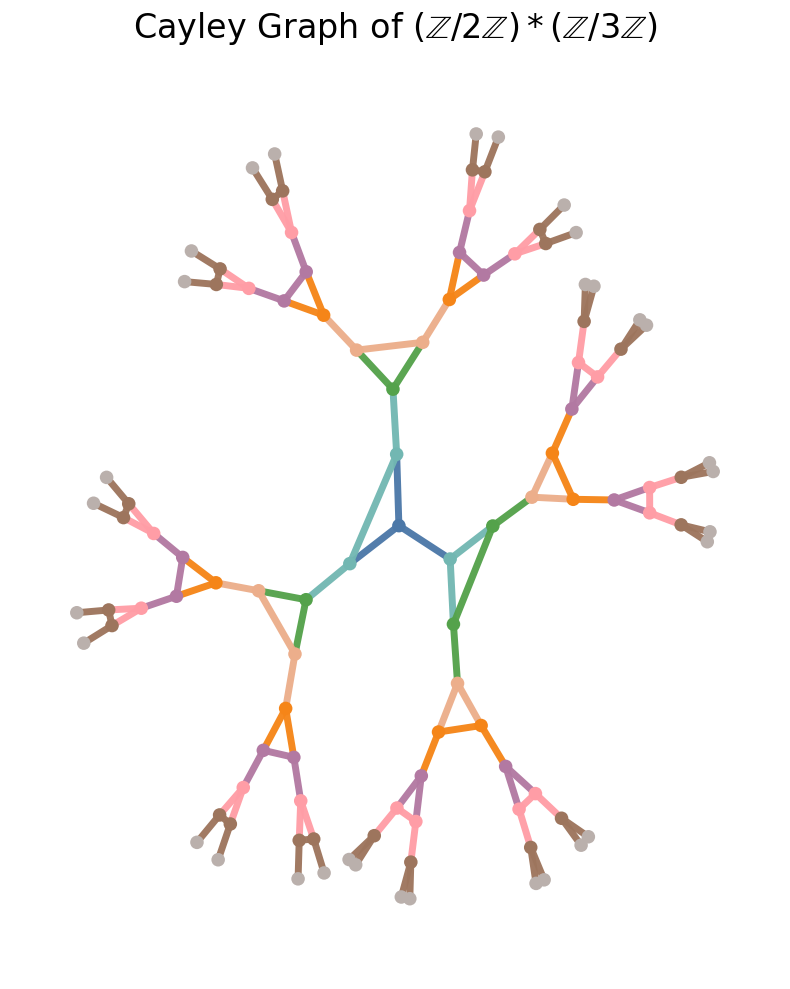

In [40]:
plt.figure(figsize=(8, 10))
plt.gca().set_facecolor('none')

nx.draw_networkx_edges(G, pos, edgelist=all_edges, width=5, edge_color=edge_colors, alpha=0.96)
nx.draw_networkx_nodes(G, pos, node_size=95, node_color=node_colors, linewidths=0)
plt.title(r'Cayley Graph of $(\mathbb{Z}/2\mathbb{Z}) * (\mathbb{Z}/3\mathbb{Z})$', pad=12, fontsize=24)

plt.axis('off')
plt.tight_layout()
plt.show()

Saved: cayley_z2_z3_handdrawn_style.png


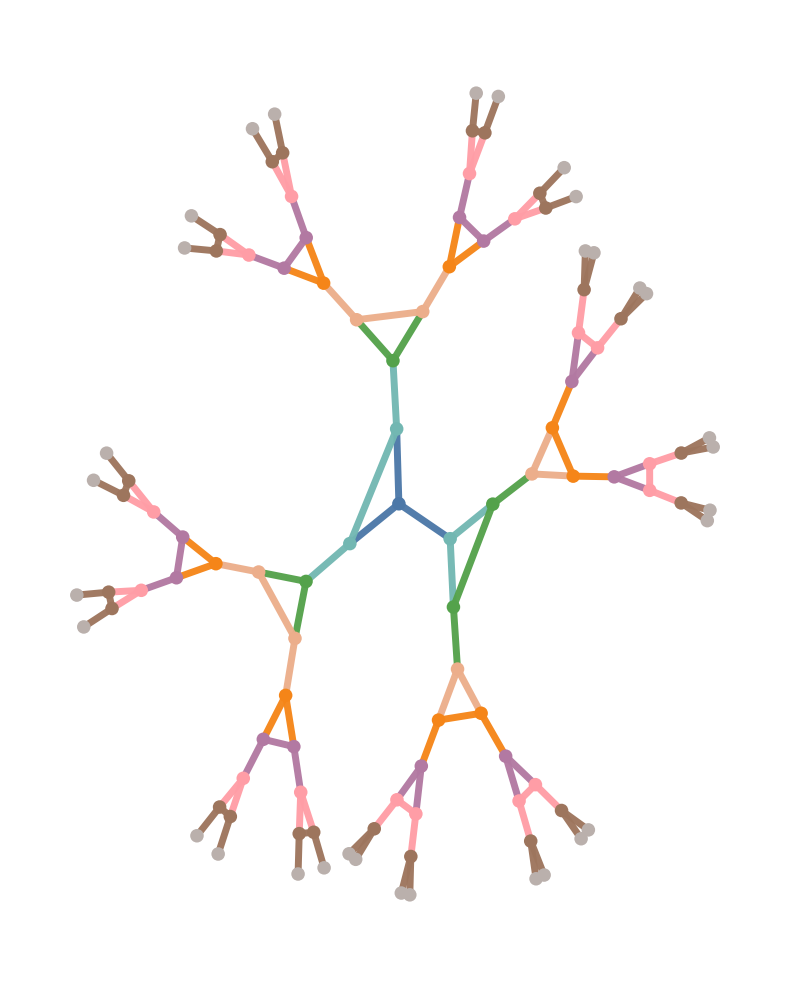

In [41]:
out_path = 'cayley_z2_z3_handdrawn_style.png'
plt.figure(figsize=(8, 10))
plt.gca().set_facecolor('none')
nx.draw_networkx_edges(G, pos, edgelist=all_edges, width=5, edge_color=edge_colors, alpha=0.96)
nx.draw_networkx_nodes(G, pos, node_size=95, node_color=node_colors, linewidths=0)
# plt.title(r'Cayley Graph of $(\mathbb{Z}/2\mathbb{Z}) * (\mathbb{Z}/3\mathbb{Z})$', pad=12, fontsize=24)
plt.axis('off')
plt.tight_layout()
plt.savefig(out_path, dpi=350, bbox_inches='tight', transparent=True)
print(f'Saved: {out_path}')